In [1]:
from joblib import Parallel, delayed
from pathlib import Path
from rdkit import Chem
import pandas as pd
import gzip
import json
import os
import re

make dict of the properties that are returned from QFP

In [2]:
with open("../data/properties.json", "r") as f:
    properties_list = json.load(f)

PROPERTY_DICT = {prop["property_db_id"]: prop["name_of_property"] for prop in properties_list}

The output files of the QFP program are given in the following format:

"example_input_{id}.json" provides a **list** of conformers. For each conformer, the xyz coordinates + bunch of properties

In [16]:
def create_molecule_df(molecule_data: list[dict], property_dict: dict[int, str] = PROPERTY_DICT) -> pd.DataFrame:
    """
    Transform the data from QuantumFP into a pandas dataframe. The dataframe consists of all QM properties extracted from QFP for each conformer of the molecule.

    params: 
        molecule_data: A list containing a dict for each conformer of the molecule with its corresponding QM properties.

    return:
        a pd.DataFrame containing the QM properties of each conformer of the molecule.
    """
    pattern = re.compile(r"prop_id")

    molecule_dict = {}
    for idx, conformer in enumerate(molecule_data):
        # Get all QM properties of a conformer and assign the proper name of the property
        conformer_dict = {property_dict[int(k.split("_")[-1])]: v for k, v in conformer.items() if pattern.search(k)}

        # Add the SMILES representations to the dataframe
        conformer_dict.update({"original_smiles": conformer["original_smiles"], "output_smiles": conformer["output_smiles"]})

        # Add the dict of the conformer to the dict of the molecule
        molecule_dict[f"conformer {idx}"] = conformer_dict
    
    return pd.DataFrame(molecule_dict).T.convert_dtypes()

In [17]:
def load_molecule_data(path: Path) -> list[dict]:
    with gzip.open(path, "rt") as f:
        data = json.load(f)
    
    return data

In [18]:
def process_molecule_data(output_file: Path) -> pd.DataFrame:
    output_data = load_molecule_data(output_file)

    return create_molecule_df(output_data)

In [19]:
def parallelize(func, iterable, n_jobs=4, backend="loky") -> list[pd.DataFrame]:
    return Parallel(n_jobs=n_jobs, backend=backend)(delayed(func)(item) for item in iterable)

In [20]:
PATH = Path("../data/QuantumFP/QFP_output")

def complete_path(path): return PATH / Path(path)

# get QFP directory path
output_files: list[Path] = list(map(complete_path, os.listdir(PATH)))

print(len(output_files))

769


In [21]:
# for each file, load the file and convert it to a df
dataframes: list[pd.DataFrame] = parallelize(process_molecule_data, output_files[:20])

In [22]:
df = dataframes[5]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, conformer 0 to conformer 1
Data columns (total 60 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   energy                                      2 non-null      Float64
 1   atomization_energy                          2 non-null      Float64
 2   homo_lumo_gap                               2 non-null      Float64
 3   ionization_energy                           2 non-null      Float64
 4   electron_affinity                           2 non-null      Float64
 5   chemical_potential                          2 non-null      Float64
 6   molecular_dipole                            2 non-null      object 
 7   molecular_dipole_norm                       2 non-null      Float64
 8   molecular_quadrupole                        2 non-null      object 
 9   molecular_quadrupole_principal_invariant_2  2 non-null      Float64
 10  mol

In [11]:
df["gibbs_free_energy"].iloc[0]

[[200.0, 101.66616116244951],
 [300.0, 83.33373538777246],
 [400.0, 60.46431473053404]]

In [12]:
import matplotlib.pyplot as plt

In [ ]:
combined_df = pd.concat(dataframes[:5], ignore_index=False)

In [14]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, conformer 0 to conformer 4
Data columns (total 60 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   energy                                      71 non-null     Float64
 1   atomization_energy                          71 non-null     Float64
 2   homo_lumo_gap                               71 non-null     Float64
 3   ionization_energy                           71 non-null     Float64
 4   electron_affinity                           71 non-null     Float64
 5   chemical_potential                          71 non-null     Float64
 6   molecular_dipole                            71 non-null     object 
 7   molecular_dipole_norm                       71 non-null     Float64
 8   molecular_quadrupole                        71 non-null     object 
 9   molecular_quadrupole_principal_invariant_2  71 non-null     Float64
 10  mo

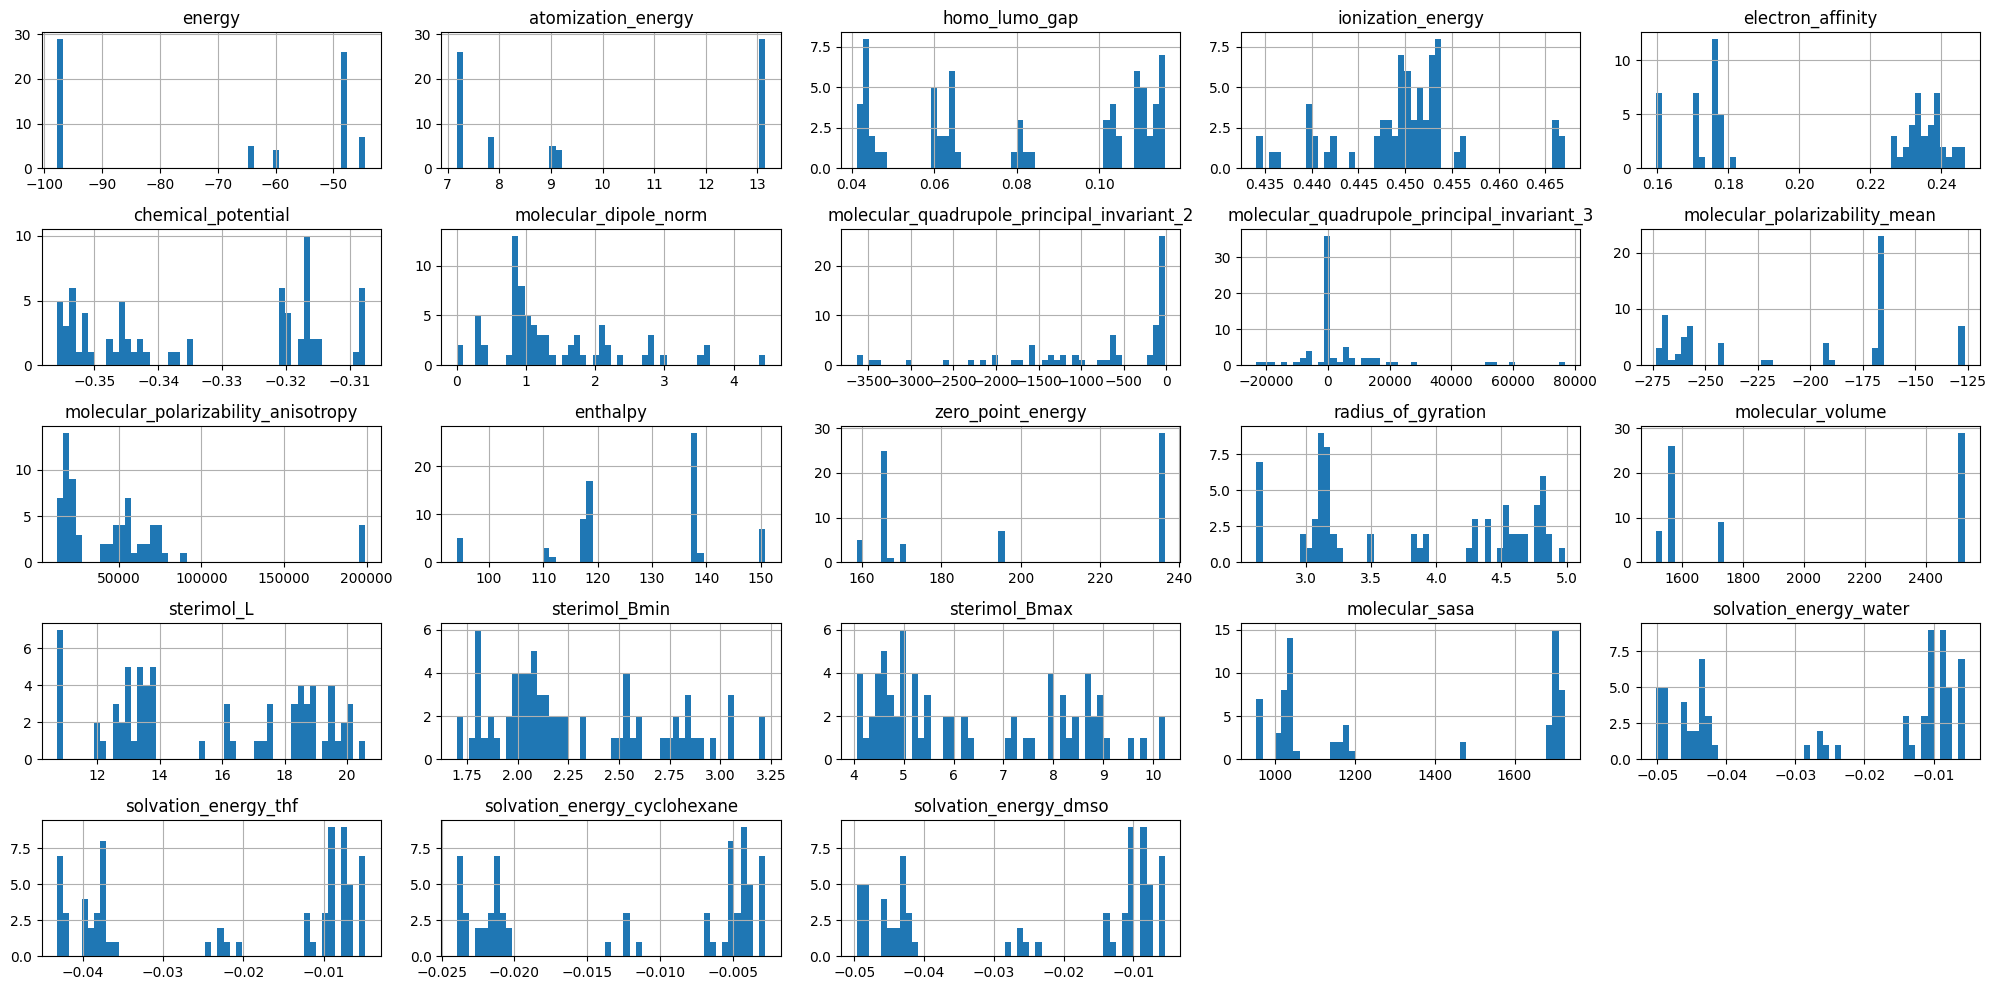

In [15]:
combined_df.hist(bins=50, figsize=(20, 10))
plt.tight_layout()

Now, after processing all molecules, we need to do a thermal averaging over the different conformers (microstates) to represent the mixture of conformers that is present in reality. 

$$
<A> = \frac{\sum_i A_i e^{-E_i \beta}}{\sum_i e^{-E_i \beta}}
$$